In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing        import LabelEncoder
from sklearn.model_selection      import train_test_split
from sklearn.metrics              import mean_absolute_error, mean_squared_error
import xgboost as xgb
 
print("Libraries loaded successfully!")
print(f"XGBoost version: {xgb.__version__}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\USER\anacondaApp\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\USER\anacondaApp\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\USER\anacondaApp\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\USER\anacondaApp\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [ ]:
%pip install xgboost scikit-learn pandas matplotlib
!python xgboost_training.py

Note: you may need to restart the kernel to use updated packages.


python: can't open file 'c:\\Users\\USER\\Machine-learning\\xgboost_training.py': [Errno 2] No such file or directory


In [ ]:
#  LOAD & CLEAN CAFETERIA DATASET
print("\n" + "="*50)
print("  CAFETERIA DATASET")
print("="*50)
 
cafe = pd.read_csv("makerere_Cafeteria_synthetic.csv")
 
# Clean currency columns (remove commas, convert to float)
currency_cols = ["Price_UGX", "Revenue_UGX", "Ingredient_Cost_UGX",
                 "Waste_Cost_UGX", "Gross_Profit_UGX"]
 
for col in currency_cols:
    cafe[col] = (cafe[col]
                 .astype(str)
                 .str.replace(",", "", regex=False)
                 .astype(float))
 
# Parse date and extract time features
cafe["Date"]       = pd.to_datetime(cafe["Date"])
cafe["Month"]      = cafe["Date"].dt.month
cafe["DayOfMonth"] = cafe["Date"].dt.day
cafe["WeekOfYear"] = cafe["Date"].dt.isocalendar().week.astype(int)
 
print("Shape:", cafe.shape)
print("Target (Gross_Profit_UGX) stats:")
print(cafe["Gross_Profit_UGX"].describe())
 
 


  CAFETERIA DATASET
Shape: (58800, 33)
Target (Gross_Profit_UGX) stats:
count    5.880000e+04
mean     1.070796e+05
std      1.165332e+05
min     -1.727200e+04
25%      3.294450e+04
50%      7.685600e+04
75%      1.369495e+05
max      1.045677e+06
Name: Gross_Profit_UGX, dtype: float64


In [ ]:
# ENCODE CATEGORICAL COLUMNS (CAFETERIA)

# XGBoost cannot process text — we convert categories to numbers
 
le = LabelEncoder()
 
cat_cols = ["Cafeteria_ID", "Cafeteria_Name", "Day_of_Week",
            "Academic_Period", "Meal"]
 
for col in cat_cols:
    cafe[col + "_enc"] = le.fit_transform(cafe[col].astype(str))
 
# Convert Is_Weekend boolean to 0/1
cafe["Is_Weekend"] = cafe["Is_Weekend"].astype(int)
 
print("\nCategorical columns encoded successfully")


Categorical columns encoded successfully


In [ ]:
#  DEFINE FEATURES & TARGET (CAFETERIA)
# Features (X) — everything the model uses to learn
# Target  (y) — what the model predicts
 
feature_cols_cafe = [
    # Encoded categoricals
    "Cafeteria_ID_enc", "Day_of_Week_enc", "Academic_Period_enc",
    "Meal_enc", "Is_Weekend",
    # Operational numbers
    "Portions_Prepared", "Portions_Sold", "Waste_Portions", "Waste_Pct",
    "Price_UGX", "Revenue_UGX", "Ingredient_Cost_UGX", "Waste_Cost_UGX",
    # Ingredient usage
    "Posho_Flour_kg", "Beans_kg", "Cooking_Oil_L", "Matooke_kg",
    "Groundnuts_kg", "Rice_kg", "Chicken_kg", "Offal_kg",
    "Onions_kg", "Irish_Potatoes_kg", "Eggs_units",
    "Wheat_Flour_kg", "Cabbage_kg", "Tomatoes_kg",
    # Time features
    "Month", "DayOfMonth", "WeekOfYear"
]
 
X_cafe = cafe[feature_cols_cafe]
y_cafe = cafe["Gross_Profit_UGX"]
 
print(f"\nFeatures shape : {X_cafe.shape}")
print(f"Target shape   : {y_cafe.shape}")


Features shape : (58800, 30)
Target shape   : (58800,)


In [ ]:
# STEP 5 — TRAIN / TEST SPLIT (CAFETERIA)
# Walk-Forward: sort by date, split chronologically
cafe_sorted = cafe.sort_values("Date")
split_idx   = int(len(cafe_sorted) * 0.8)   # 80% train, 20% test
 
X_train_cafe = cafe_sorted[feature_cols_cafe].iloc[:split_idx]
X_test_cafe  = cafe_sorted[feature_cols_cafe].iloc[split_idx:]
y_train_cafe = cafe_sorted["Gross_Profit_UGX"].iloc[:split_idx]
y_test_cafe  = cafe_sorted["Gross_Profit_UGX"].iloc[split_idx:]
 
print(f"\nTrain size : {len(X_train_cafe):,} rows")
print(f"Test size  : {len(X_test_cafe):,} rows")


Train size : 47,040 rows
Test size  : 11,760 rows


In [ ]:
# TRAIN XGBOOST (CAFETERIA)

xgb_cafe = xgb.XGBRegressor(
    n_estimators      = 300,    # number of trees
    max_depth         = 6,      # depth of each tree
    learning_rate     = 0.05,   # step size (lower = more careful)
    subsample         = 0.8,    # 80% of rows per tree (prevents overfitting)
    colsample_bytree  = 0.8,    # 80% of features per tree
    min_child_weight  = 5,      # minimum samples in a leaf
    reg_alpha         = 0.1,    # L1 regularisation
    reg_lambda        = 1.0,    # L2 regularisation
    random_state      = 42,
    n_jobs            = -1,     # use all CPU cores
    verbosity         = 1
)
 
print("\nTraining XGBoost on Cafeteria dataset...")
xgb_cafe.fit(
    X_train_cafe, y_train_cafe,
    eval_set=[(X_test_cafe, y_test_cafe)],
    verbose=50   
)
print("Cafeteria model training complete!")
 
 

# EVALUATE (CAFETERIA)

y_pred_cafe = xgb_cafe.predict(X_test_cafe)
 
mae_cafe  = mean_absolute_error(y_test_cafe, y_pred_cafe)
rmse_cafe = np.sqrt(mean_squared_error(y_test_cafe, y_pred_cafe))
mape_cafe = np.mean(np.abs((y_test_cafe - y_pred_cafe) / y_test_cafe)) * 100
 
print(f"\n{'='*45}")
print(f"  XGBoost — CAFETERIA Performance")
print(f"{'='*45}")
print(f"  MAE  : {mae_cafe:,.0f} UGX")
print(f"  RMSE : {rmse_cafe:,.0f} UGX")
print(f"  MAPE : {mape_cafe:.2f}%")
 
 


Training XGBoost on Cafeteria dataset...
[0]	validation_0-rmse:110578.30432
[50]	validation_0-rmse:11011.23138
[100]	validation_0-rmse:3849.64532
[150]	validation_0-rmse:2897.30099
[200]	validation_0-rmse:2631.44364
[250]	validation_0-rmse:2500.40404
[299]	validation_0-rmse:2420.68212
Cafeteria model training complete!

  XGBoost — CAFETERIA Performance
  MAE  : 1,223 UGX
  RMSE : 2,421 UGX
  MAPE : 2.07%



Top 10 Most Important Features (Cafeteria):
          Feature  Importance
    Portions_Sold    0.626491
Portions_Prepared    0.281453
      Revenue_UGX    0.023612
         Meal_enc    0.019219
        Price_UGX    0.010696
Irish_Potatoes_kg    0.007915
        Waste_Pct    0.007778
       Eggs_units    0.005247
   Waste_Cost_UGX    0.003703
       Chicken_kg    0.003333


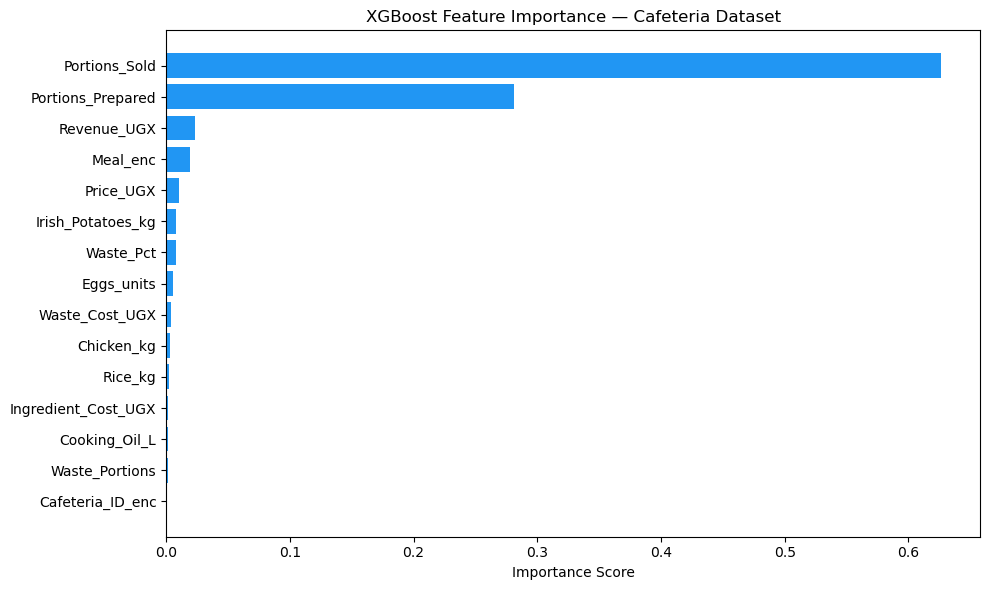

Plot saved: xgb_cafeteria_feature_importance.png


In [ ]:
#FEATURE IMPORTANCE (CAFETERIA)

importance_cafe = pd.DataFrame({
    "Feature"   : feature_cols_cafe,
    "Importance": xgb_cafe.feature_importances_
}).sort_values("Importance", ascending=False)
 
print("\nTop 10 Most Important Features (Cafeteria):")
print(importance_cafe.head(10).to_string(index=False))
 
# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_cafe["Feature"].head(15)[::-1],
         importance_cafe["Importance"].head(15)[::-1],
         color="#2196F3")
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance — Cafeteria Dataset")
plt.tight_layout()
plt.savefig("xgb_cafeteria_feature_importance.png", dpi=150)
plt.show()
print("Plot saved: xgb_cafeteria_feature_importance.png")

In [ ]:
# LOAD & CLEAN KIOSK DATASET

print("\n" + "="*50)
print("  KIOSK DATASET")
print("="*50)
 
kiosk = pd.read_csv("makerere_kiosk_synthetic.csv")
 
# Clean currency columns
for col in ["Unit_Price_UGX", "Total_Amount_UGX"]:
    kiosk[col] = (kiosk[col]
                  .astype(str)
                  .str.replace(",", "", regex=False)
                  .astype(float))
 
# Parse date and extract time features
kiosk["Date"]       = pd.to_datetime(kiosk["Date"])
kiosk["Month"]      = kiosk["Date"].dt.month
kiosk["DayOfMonth"] = kiosk["Date"].dt.day
kiosk["WeekOfYear"] = kiosk["Date"].dt.isocalendar().week.astype(int)
 
# Encode booleans
kiosk["Is_Weekend"]        = kiosk["Is_Weekend"].astype(int)
kiosk["Near_Lecture_Start"]= kiosk["Near_Lecture_Start"].astype(int)
 
print("Shape:", kiosk.shape)


  KIOSK DATASET
Shape: (158985, 20)


In [ ]:
#  ENCODE CATEGORICALS (KIOSK)

cat_cols_kiosk = ["Day_of_Week", "Academic_Period", "Kiosk_ID",
                  "Kiosk_Location", "Item", "Payment_Method"]
 
for col in cat_cols_kiosk:
    kiosk[col + "_enc"] = le.fit_transform(kiosk[col].astype(str))
 
print("Categorical columns encoded successfully")
 
 

#FEATURES & TARGET (KIOSK)

feature_cols_kiosk = [
    "Hour", "Is_Weekend", "Near_Lecture_Start",
    "Day_of_Week_enc", "Academic_Period_enc",
    "Kiosk_ID_enc", "Kiosk_Location_enc",
    "Item_enc", "Payment_Method_enc",
    "Quantity", "Unit_Price_UGX", "Price_vs_Base_Pct",
    "Month", "DayOfMonth", "WeekOfYear"
]
 
X_kiosk = kiosk[feature_cols_kiosk]
y_kiosk = kiosk["Total_Amount_UGX"]
 
print(f"\nFeatures shape : {X_kiosk.shape}")
print(f"Target shape   : {y_kiosk.shape}")

Categorical columns encoded successfully

Features shape : (158985, 15)
Target shape   : (158985,)


In [ ]:
# TRAIN / TEST SPLIT (KIOSK)

kiosk_sorted = kiosk.sort_values("Date")
split_idx_k  = int(len(kiosk_sorted) * 0.8)
 
X_train_kiosk = kiosk_sorted[feature_cols_kiosk].iloc[:split_idx_k]
X_test_kiosk  = kiosk_sorted[feature_cols_kiosk].iloc[split_idx_k:]
y_train_kiosk = kiosk_sorted["Total_Amount_UGX"].iloc[:split_idx_k]
y_test_kiosk  = kiosk_sorted["Total_Amount_UGX"].iloc[split_idx_k:]
 
print(f"\nTrain size : {len(X_train_kiosk):,} rows")
print(f"Test size  : {len(X_test_kiosk):,} rows")
 
 

# STEP 13 — TRAIN XGBOOST (KIOSK)

xgb_kiosk = xgb.XGBRegressor(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 1
)
 
print("\nTraining XGBoost on Kiosk dataset...")
xgb_kiosk.fit(
    X_train_kiosk, y_train_kiosk,
    eval_set=[(X_test_kiosk, y_test_kiosk)],
    verbose=50
)
print("Kiosk model training complete!")


Train size : 127,188 rows
Test size  : 31,797 rows

Training XGBoost on Kiosk dataset...
[0]	validation_0-rmse:734.12450
[50]	validation_0-rmse:62.41704
[100]	validation_0-rmse:5.16654
[150]	validation_0-rmse:1.37828
[200]	validation_0-rmse:1.14529
[250]	validation_0-rmse:0.99976
[299]	validation_0-rmse:0.90346
Kiosk model training complete!



  XGBoost — KIOSK Performance
  MAE  : 0 UGX
  RMSE : 1 UGX
  MAPE : 0.06%

Top 10 Most Important Features (Kiosk):
            Feature  Importance
     Unit_Price_UGX    0.577622
           Item_enc    0.405597
  Price_vs_Base_Pct    0.016419
 Payment_Method_enc    0.000049
Academic_Period_enc    0.000045
         DayOfMonth    0.000043
 Near_Lecture_Start    0.000042
 Kiosk_Location_enc    0.000035
         WeekOfYear    0.000033
         Is_Weekend    0.000031


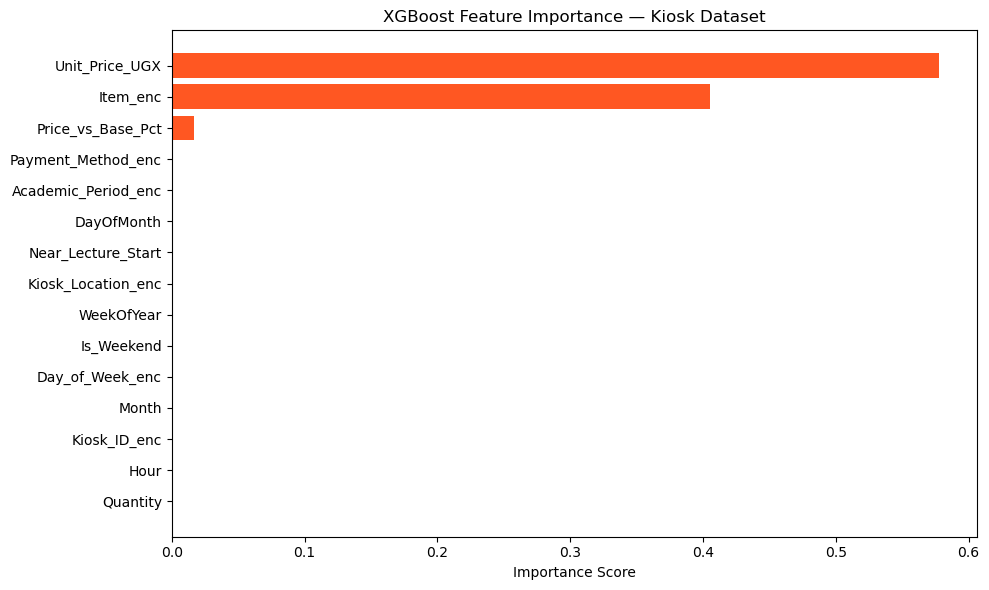

Plot saved: xgb_kiosk_feature_importance.png


In [ ]:
# STEP 14 — EVALUATE (KIOSK)
# ============================================================
y_pred_kiosk = xgb_kiosk.predict(X_test_kiosk)
 
mae_kiosk  = mean_absolute_error(y_test_kiosk, y_pred_kiosk)
rmse_kiosk = np.sqrt(mean_squared_error(y_test_kiosk, y_pred_kiosk))
mape_kiosk = np.mean(np.abs((y_test_kiosk - y_pred_kiosk) / y_test_kiosk)) * 100
 
print(f"\n{'='*45}")
print(f"  XGBoost — KIOSK Performance")
print(f"{'='*45}")
print(f"  MAE  : {mae_kiosk:,.0f} UGX")
print(f"  RMSE : {rmse_kiosk:,.0f} UGX")
print(f"  MAPE : {mape_kiosk:.2f}%")
 
 
# ============================================================
# STEP 15 — FEATURE IMPORTANCE (KIOSK)
# ============================================================
importance_kiosk = pd.DataFrame({
    "Feature"   : feature_cols_kiosk,
    "Importance": xgb_kiosk.feature_importances_
}).sort_values("Importance", ascending=False)
 
print("\nTop 10 Most Important Features (Kiosk):")
print(importance_kiosk.head(10).to_string(index=False))
 
plt.figure(figsize=(10, 6))
plt.barh(importance_kiosk["Feature"].head(15)[::-1],
         importance_kiosk["Importance"].head(15)[::-1],
         color="#FF5722")
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance — Kiosk Dataset")
plt.tight_layout()
plt.savefig("xgb_kiosk_feature_importance.png", dpi=150)
plt.show()
print("Plot saved: xgb_kiosk_feature_importance.png")

In [10]:
# ── XAI 3: Partial Dependence Plots (PDP) + ICE curves ──────
from sklearn.inspection import PartialDependenceDisplay

# PDP shows: "as Revenue_UGX increases, how does predicted Gross_Profit change?"
# ICE shows the same but for every individual row — reveals heterogeneity

top_features_cafe  = ["Revenue_UGX", "Ingredient_Cost_UGX",
                       "Portions_Sold", "Waste_Pct"]
top_features_kiosk = ["Unit_Price_UGX", "Quantity",
                       "Hour", "Near_Lecture_Start"]

# Cafeteria PDP
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    xgb_cafe, X_test_cafe,
    features=top_features_cafe,
    kind="both",          # "both" = PDP (mean line) + ICE (individual lines)
    subsample=200,        # ICE on 200 random rows for clarity
    ax=ax.ravel(),
    random_state=42
)
plt.suptitle("Partial Dependence + ICE Plots — Cafeteria XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("pdp_ice_cafeteria.png", dpi=150, bbox_inches="tight")
plt.show()

# Kiosk PDP
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    xgb_kiosk, X_test_kiosk,
    features=top_features_kiosk,
    kind="both",
    subsample=200,
    ax=ax.ravel(),
    random_state=42
)
plt.suptitle("Partial Dependence + ICE Plots — Kiosk XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("pdp_ice_kiosk.png", dpi=150, bbox_inches="tight")
plt.show()

print("PDP + ICE plots saved.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\USER\anacondaApp\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\USER\anacondaApp\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\USER\anacondaApp\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\USER\anacondaApp\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import